In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report)
import json, os

In [3]:
# Read the ARFF file manually (it was saved as df.md but the content is ARFF format)
with open(r'C:\Users\ADMIN\Downloads\AIML_PROJECT_OFFICIAL_Y2S1\MLBG11.02_07_AIML\data\raw\Rice_Cammeo_Osmancik.arff', 'r') as f:
    lines = f.readlines()

# Column names, in the order they appear in @ATTRIBUTE lines
columns = ['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length',
           'Eccentricity', 'Convex_Area', 'Extent', 'Class']

# Find where the actual data starts (after the @DATA line)
data_start = next(i for i, l in enumerate(lines) if l.strip().upper() == '@DATA') + 1
data_lines = [l.strip() for l in lines[data_start:] if l.strip()]

# Parse into a DataFrame
rows = [l.split(',') for l in data_lines]
df = pd.DataFrame(rows, columns=columns)

# Convert numeric columns from text to actual numbers
num_cols = columns[:-1]
df[num_cols] = df[num_cols].astype(float)

# Save a clean CSV for every other notebook to reuse
df.to_csv(r'C:\Users\ADMIN\Downloads\AIML_PROJECT_OFFICIAL_Y2S1\MLBG11.02_07_AIML\data\raw\rice.csv', index=False)

print(df.shape)
df.head()


(3810, 8)


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231.0,525.578979,229.749878,85.093788,0.928882,15617.0,0.572896,Cammeo
1,14656.0,494.311005,206.020065,91.730972,0.895405,15072.0,0.615436,Cammeo
2,14634.0,501.122009,214.106781,87.768288,0.912118,14954.0,0.693259,Cammeo
3,13176.0,458.342987,193.337387,87.448395,0.891861,13368.0,0.640669,Cammeo
4,14688.0,507.166992,211.743378,89.312454,0.906691,15262.0,0.646024,Cammeo


In [4]:
X = df.drop(columns=['Class'])
y = df['Class']

# Fixed split shared by ALL member notebooks so results are directly comparable
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (3048, 7)  Test: (762, 7)


In [5]:
#Hyperparameter tuning with GridSearchCV (5-fold)
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')

param_grid = {
    'hidden_layer_sizes': [(16,), (32,), (32, 16)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}

grid = GridSearchCV(
    MLPClassifier(max_iter=1000, early_stopping=True, random_state=42),
    param_grid, cv=5, scoring='f1', n_jobs=-1
)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_params = grid.best_params_
print("Best params:", best_params)


Best params: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (16,), 'learning_rate_init': 0.001}


In [6]:
#K-fold cross-validation on the training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='accuracy')
print("CV accuracy per fold:", cv_scores.round(4))
print(f"CV mean accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


CV accuracy per fold: [0.5852 0.577  0.5656 0.5895 0.5731]
CV mean accuracy: 0.5781 (+/- 0.0085)


FileNotFoundError: [Errno 2] No such file or directory: '../results/eda_visualizations/mlp_loss_curve.png'

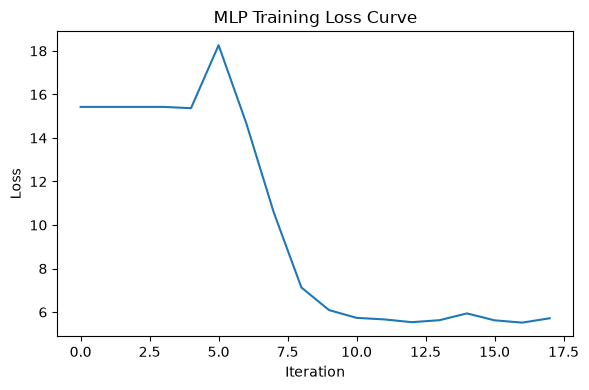

In [7]:
#Training loss curve
plt.figure(figsize=(6,4))
plt.plot(best_model.loss_curve_)
plt.xlabel('Iteration'); plt.ylabel('Loss')
plt.title('MLP Training Loss Curve')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/mlp_loss_curve.png', dpi=150)
plt.show()


Test Accuracy : 0.5630
Test Precision: 0.2941
Test Recall   : 0.0153
Test F1-score : 0.0292

              precision    recall  f1-score   support

      Cammeo       0.29      0.02      0.03       326
    Osmancik       0.57      0.97      0.72       436

    accuracy                           0.56       762
   macro avg       0.43      0.49      0.37       762
weighted avg       0.45      0.56      0.42       762



FileNotFoundError: [Errno 2] No such file or directory: '../results/eda_visualizations/neural_network_confusion_matrix.png'

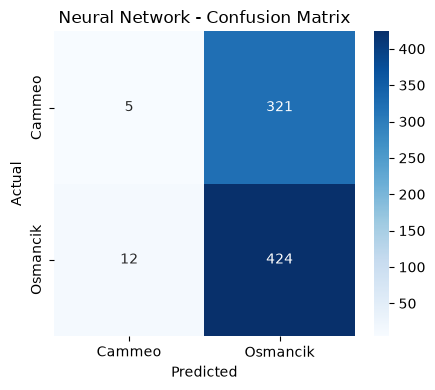

In [8]:
# Evaluate on the held-out test set
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label='Cammeo')
rec = recall_score(y_test, y_pred, pos_label='Cammeo')
f1 = f1_score(y_test, y_pred, pos_label='Cammeo')

print(f"Test Accuracy : {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall   : {rec:.4f}")
print(f"Test F1-score : {f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Cammeo', 'Osmancik']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cammeo', 'Osmancik'], yticklabels=['Cammeo', 'Osmancik'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Neural Network - Confusion Matrix')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/neural_network_confusion_matrix.png', dpi=150)
plt.show()

In [9]:
#Save results for the group comparison notebook
os.makedirs('../results/logs', exist_ok=True)
results = {
    'member': 'IT2510059',
    'model': 'Neural Network',
    'best_params': best_params,
    'cv_mean_accuracy': round(float(cv_scores.mean()), 4),
    'cv_std_accuracy': round(float(cv_scores.std()), 4),
    'test_accuracy': round(float(acc), 4),
    'test_precision': round(float(prec), 4),
    'test_recall': round(float(rec), 4),
    'test_f1': round(float(f1), 4),
}
with open('../results/logs/Member6_Neural_Network_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))


{
  "member": "IT2510059",
  "model": "Neural Network",
  "best_params": {
    "activation": "relu",
    "alpha": 0.0001,
    "hidden_layer_sizes": [
      16
    ],
    "learning_rate_init": 0.001
  },
  "cv_mean_accuracy": 0.5781,
  "cv_std_accuracy": 0.0085,
  "test_accuracy": 0.563,
  "test_precision": 0.2941,
  "test_recall": 0.0153,
  "test_f1": 0.0292
}
